In [1]:
!pip install pandas

In [2]:
#Import library
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
#Read Dataset
df = pd.read_csv('https://raw.githubusercontent.com/YBIFoundation/ProjectDataSet/main/ShopSmart%20Customer%20Segmentation.csv')

In [4]:
#Explore data
df.head(10)

,Customer_ID,Age,Annual_Income,Spending_Score,Total_Purchases,Avg_Order_Value,Days_Since_Last_Purchase
0,1001,56,1285317,65,35,3659,186
1,1002,46,200000,28,13,1494,281
2,1003,32,410079,34,12,1359,292
3,1004,60,593717,38,19,3291,254
4,1005,25,509148,31,12,2813,280
5,1006,38,324049,11,16,500,304
6,1007,56,398689,30,12,2276,252
7,1008,36,345759,27,18,1834,276
8,1009,40,329495,27,14,500,267
9,1010,28,676576,27,11,3056,309


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Customer_ID               500 non-null    int64
 1   Age                       500 non-null    int64
 2   Annual_Income             500 non-null    int64
 3   Spending_Score            500 non-null    int64
 4   Total_Purchases           500 non-null    int64
 5   Avg_Order_Value           500 non-null    int64
 6   Days_Since_Last_Purchase  500 non-null    int64
dtypes: int64(7)
memory usage: 27.5 KB


In [6]:
df.describe()

,Customer_ID,Age,Annual_Income,Spending_Score,Total_Purchases,Avg_Order_Value,Days_Since_Last_Purchase
count,500.000000,500.000000,5.000000e+02,500.000000,500.000000,500.000000,500.000000
mean,1250.500000,41.278000,5.003012e+05,31.744000,17.644000,1781.042000,269.774000
std,144.481833,13.389072,2.648204e+05,12.585199,5.830029,1210.234041,43.064231
min,1001.000000,18.000000,2.000000e+05,1.000000,5.000000,500.000000,107.000000
25%,1125.750000,30.000000,3.116715e+05,24.000000,13.750000,738.750000,244.750000
50%,1250.500000,42.000000,4.382815e+05,31.000000,17.000000,1492.500000,273.000000
75%,1375.250000,52.000000,6.063188e+05,38.000000,21.000000,2546.250000,299.250000
max,1500.000000,64.000000,2.062522e+06,85.000000,40.000000,7320.000000,365.000000


In [7]:
df.isnull().sum()

,0
Customer_ID,0
Age,0
Annual_Income,0
Spending_Score,0
Total_Purchases,0
Avg_Order_Value,0
Days_Since_Last_Purchase,0


In [8]:
#Visualize Income Distribution

(array([103.,  93.,  92.,  63.,  52.,  29.,  20.,  12.,  12.,   9.,   3.,
          5.,   2.,   1.,   1.,   2.,   0.,   0.,   0.,   1.]),
 array([ 200000. ,  293126.1,  386252.2,  479378.3,  572504.4,  665630.5,
         758756.6,  851882.7,  945008.8, 1038134.9, 1131261. , 1224387.1,
        1317513.2, 1410639.3, 1503765.4, 1596891.5, 1690017.6, 1783143.7,
        1876269.8, 1969395.9, 2062522. ]),
 <BarContainer object of 20 artists>)

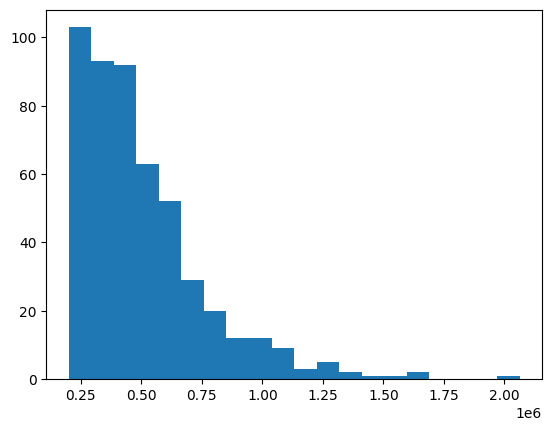

In [9]:
fig, ax = plt.subplots()
ax.hist(df['Annual_Income'],bins = 20)

(array([ 2.,  7., 17., 28., 46., 77., 70., 67., 63., 35., 40., 16., 11.,
         2., 10.,  4.,  1.,  1.,  2.,  1.]),
 array([ 1. ,  5.2,  9.4, 13.6, 17.8, 22. , 26.2, 30.4, 34.6, 38.8, 43. ,
        47.2, 51.4, 55.6, 59.8, 64. , 68.2, 72.4, 76.6, 80.8, 85. ]),
 <BarContainer object of 20 artists>)

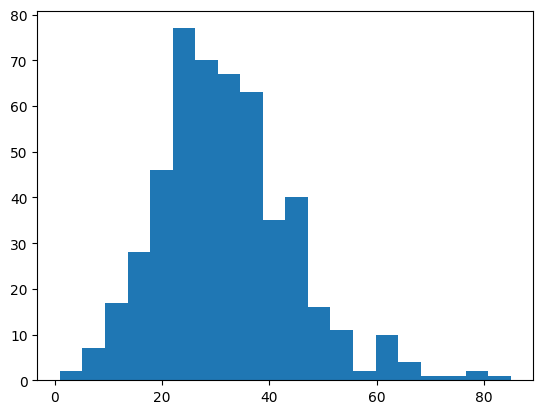

In [10]:
#Spending Score Distribution
fig, ax = plt.subplots()
ax.hist(df['Spending_Score'], bins = 20)

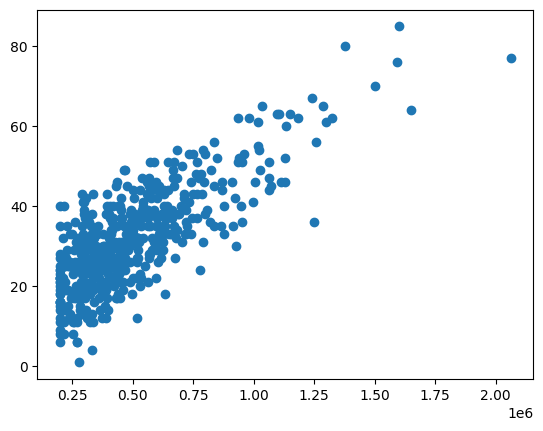

In [11]:
#Scatter Plot
fig, ax = plt.subplots()
ax.scatter(df['Annual_Income'], df['Spending_Score'])

In [12]:
#Define Features (X)
df.columns

Index(['Customer_ID', 'Age', 'Annual_Income', 'Spending_Score',
       'Total_Purchases', 'Avg_Order_Value', 'Days_Since_Last_Purchase'],
      dtype='object')

In [13]:
X = df[['Age', 'Annual_Income', 'Spending_Score',
       'Total_Purchases', 'Avg_Order_Value', 'Days_Since_Last_Purchase']]

In [14]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()

In [15]:
X_scale = ss.fit_transform(X)

In [16]:
#Select KMeans Model
from sklearn.cluster import KMeans

In [17]:
model = KMeans(n_clusters=4)

In [18]:
#Segmentation
model.fit(X_scale)

KMeans(n_clusters=4)

In [19]:
model.predict(X_scale)

array([3, 0, 1, 2, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 2, 1, 1, 1, 2, 0, 0, 0,
       2, 1, 2, 1, 0, 2, 2, 2, 2, 1, 2, 1, 0, 0, 1, 2, 1, 3, 1, 0, 2, 2,
       0, 1, 1, 1, 1, 1, 2, 0, 1, 0, 2, 0, 1, 2, 1, 0, 0, 2, 1, 2, 0, 1,
       1, 2, 2, 0, 2, 1, 0, 1, 0, 1, 1, 2, 0, 2, 2, 1, 0, 0, 0, 0, 1, 0,
       2, 2, 3, 0, 0, 2, 3, 1, 1, 0, 1, 0, 2, 2, 2, 2, 2, 0, 0, 0, 1, 3,
       2, 0, 1, 2, 0, 2, 1, 0, 0, 0, 0, 0, 1, 0, 0, 2, 2, 0, 1, 2, 0, 0,
       2, 1, 2, 1, 3, 2, 0, 2, 2, 2, 1, 0, 2, 1, 1, 0, 1, 1, 2, 0, 2, 0,
       0, 1, 0, 0, 0, 1, 0, 2, 1, 1, 1, 0, 0, 2, 1, 2, 0, 0, 0, 0, 1, 0,
       3, 2, 0, 1, 0, 2, 0, 2, 0, 1, 1, 1, 1, 2, 2, 1, 0, 1, 3, 2, 0, 1,
       1, 1, 0, 1, 1, 0, 2, 2, 1, 2, 1, 1, 2, 0, 1, 1, 1, 0, 2, 3, 1, 0,
       1, 1, 1, 0, 0, 1, 2, 1, 0, 1, 1, 2, 2, 1, 1, 2, 1, 0, 0, 2, 0, 1,
       1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 2, 0, 2, 1, 2, 2, 0, 1, 2, 1,
       2, 1, 1, 1, 2, 0, 1, 0, 0, 2, 0, 1, 0, 2, 2, 1, 2, 1, 1, 0, 1, 1,
       0, 2, 0, 1, 2, 1, 0, 0, 1, 2, 2, 0, 0, 3, 1,

In [20]:
df['Cluster'] = model.fit_predict(X_scale)

In [21]:
df

,Customer_ID,Age,Annual_Income,Spending_Score,Total_Purchases,Avg_Order_Value,Days_Since_Last_Purchase,Cluster
0,1001,56,1285317,65,35,3659,186,3
1,1002,46,200000,28,13,1494,281,2
2,1003,32,410079,34,12,1359,292,0
3,1004,60,593717,38,19,3291,254,1
4,1005,25,509148,31,12,2813,280,0
...,...,...,...,...,...,...,...,...
495,1496,37,603400,32,18,2014,266,0
496,1497,41,483521,31,24,1432,269,0
497,1498,29,226914,19,14,838,319,2
498,1499,52,535041,38,14,1622,263,0
